## EDA And Feature Engineering Flight Price Prediction
check the dataset info below
https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction

### FEATURES
The various features of the cleaned dataset are explained below:
1) Airline: The name of the airline company is stored in the airline column. It is a categorical feature having 6 different airlines.
2) Flight: Flight stores information regarding the plane's flight code. It is a categorical feature.
3) Source City: City from which the flight takes off. It is a categorical feature having 6 unique cities.
4) Departure Time: This is a derived categorical feature obtained created by grouping time periods into bins. It stores information about the departure time and have 6 unique time labels.
5) Stops: A categorical feature with 3 distinct values that stores the number of stops between the source and destination cities.
6) Arrival Time: This is a derived categorical feature created by grouping time intervals into bins. It has six distinct time labels and keeps information about the arrival time.
7) Destination City: City where the flight will land. It is a categorical feature having 6 unique cities.
8) Class: A categorical feature that contains information on seat class; it has two distinct values: Business and Economy.
9) Duration: A continuous feature that displays the overall amount of time it takes to travel between cities in hours.
10)Days Left: This is a derived characteristic that is calculated by subtracting the trip date by the booking date.
11) Price: Target variable stores information of the ticket price.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df= pd.read_excel('flight_price.xlsx')
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [3]:
df.describe()

,Price
count,10683.000000
mean,9087.064121
std,4611.359167
min,1759.000000
25%,5277.000000
50%,8372.000000
75%,12373.000000
max,79512.000000


In [4]:
df.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

In [5]:
df['Day']= df['Date_of_Journey'].str.split('/').str[0]
df['Month']= df['Date_of_Journey'].str.split('/').str[1]
df['Year']= df['Date_of_Journey'].str.split('/').str[2]

In [6]:
df.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,03,2019
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,05,2019
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,06,2019
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,05,2019
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,01,03,2019


In [7]:
df['Day']= df['Day'].astype(int)
df['Month']= df['Month'].astype(int)
df['Year']= df['Year'].astype(int)
df.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
Day                 int64
Month               int64
Year                int64
dtype: object

In [8]:
df.drop('Date_of_Journey', axis=1, inplace=True)

In [9]:
df.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897,24,3,2019
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882,9,6,2019
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019


In [10]:
df['Arrival_Time']= df['Arrival_Time'].str.split(' ').str[0]    

In [11]:
df['Arrival_Hour']=df['Arrival_Time'].str.split(':').str[0]
df['Arrival_Minute']=df['Arrival_Time'].str.split(':').str[1]

In [12]:
df.head()

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Arrival_Hour,Arrival_Minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10,2h 50m,non-stop,No info,3897,24,3,2019,01,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662,1,5,2019,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25,19h,2 stops,No info,13882,9,6,2019,04,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218,12,5,2019,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302,1,3,2019,21,35


In [13]:
df['Arrival_Hour'] = df['Arrival_Hour'].astype(int)
df['Arrival_Minute'] = df['Arrival_Minute'].astype(int)

In [14]:
df.drop('Arrival_Time', axis=1, inplace=True)
df.dtypes

Airline            object
Source             object
Destination        object
Route              object
Dep_Time           object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
Day                 int64
Month               int64
Year                int64
Arrival_Hour        int64
Arrival_Minute      int64
dtype: object

In [15]:
df['Departure_hour']=df['Dep_Time'].str.split(':').str[0]
df['Departure_minute']=df['Dep_Time'].str.split(':').str[1]
df.drop('Dep_Time',axis=1, inplace=True )
df['Departure_hour']= df['Departure_hour'].astype(int)
df['Departure_minute']= df['Departure_minute'].astype(int)
df.dtypes

Airline             object
Source              object
Destination         object
Route               object
Duration            object
Total_Stops         object
Additional_Info     object
Price                int64
Day                  int64
Month                int64
Year                 int64
Arrival_Hour         int64
Arrival_Minute       int64
Departure_hour       int64
Departure_minute     int64
dtype: object

In [16]:
df.head(2)

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Arrival_Hour,Arrival_Minute,Departure_hour,Departure_minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,non-stop,No info,3897,24,3,2019,1,10,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2 stops,No info,7662,1,5,2019,13,15,5,50


In [17]:
print(df['Total_Stops'].unique())
print(df['Total_Stops'].isnull().sum())

['non-stop' '2 stops' '1 stop' '3 stops' nan '4 stops']
1


In [18]:
df[df['Total_Stops'].isnull()==True]

,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Arrival_Hour,Arrival_Minute,Departure_hour,Departure_minute
9039,Air India,Delhi,Cochin,NaN,23h 40m,NaN,No info,7480,6,5,2019,9,25,9,45


In [19]:
df['Total_Stops'].mode()

0    1 stop
Name: Total_Stops, dtype: object

In [20]:
df['Total_Stops']=df['Total_Stops'].map({
    'non-stop':0,
    '1 stop':1,
    '2 stops':2,
    '3 stops':3,
    '4 stops':4,
    np.nan:1,
})
df


,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Arrival_Hour,Arrival_Minute,Departure_hour,Departure_minute
0,IndiGo,Banglore,New Delhi,BLR → DEL,2h 50m,0,No info,3897,24,3,2019,1,10,22,20
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,7h 25m,2,No info,7662,1,5,2019,13,15,5,50
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,19h,2,No info,13882,9,6,2019,4,25,9,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,5h 25m,1,No info,6218,12,5,2019,23,30,18,5
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,4h 45m,1,No info,13302,1,3,2019,21,35,16,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,2h 30m,0,No info,4107,9,4,2019,22,25,19,55
10679,Air India,Kolkata,Banglore,CCU → BLR,2h 35m,0,No info,4145,27,4,2019,23,20,20,45
10680,Jet Airways,Banglore,Delhi,BLR → DEL,3h,0,No info,7229,27,4,2019,11,20,8,20
10681,Vistara,Banglore,New Delhi,BLR → DEL,2h 40m,0,No info,12648,1,3,2019,14,10,11,30


In [21]:
df[df['Total_Stops'].isnull()==True]


,Airline,Source,Destination,Route,Duration,Total_Stops,Additional_Info,Price,Day,Month,Year,Arrival_Hour,Arrival_Minute,Departure_hour,Departure_minute


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Airline           10683 non-null  object
 1   Source            10683 non-null  object
 2   Destination       10683 non-null  object
 3   Route             10682 non-null  object
 4   Duration          10683 non-null  object
 5   Total_Stops       10683 non-null  int64 
 6   Additional_Info   10683 non-null  object
 7   Price             10683 non-null  int64 
 8   Day               10683 non-null  int64 
 9   Month             10683 non-null  int64 
 10  Year              10683 non-null  int64 
 11  Arrival_Hour      10683 non-null  int64 
 12  Arrival_Minute    10683 non-null  int64 
 13  Departure_hour    10683 non-null  int64 
 14  Departure_minute  10683 non-null  int64 
dtypes: int64(9), object(6)
memory usage: 1.2+ MB


In [23]:
# # Create the new columns first
# df['dur_hr'] = 0  # Initialize with default values
# df['dur_min'] = 0

# # Now your existing loop will work
# for row in range(len(df['Duration'])):
#     if 'h' and 'm' in df['Duration'][row]:
#         df['dur_hr'][row]=df['Duration'][row].split(' ')[0].split('h')[0]
#         df['dur_hr'][row]=int(df['dur_hr'][row])
#         df['dur_min'][row]=df['Duration'][row].split(' ')[1].split('m')[0]
#         df['dur_min'][row]=int(df['dur_min'][row])
#     elif 'h' in df['Duration'][row]:
#         df['dur_hr'][row]=df['Duration'][row].split('h')[0]
#         df['dur_hr'][row]=int(df['dur_hr'][row])
#         df['dur_min'][row]=0
#     elif 'm' in df['Duration'][row]:
#         df['dur_min'][row]=df['Duration'][row].split('m')[0]
#         df['dur_min'][row]=int(df['dur_min'][row])
#         df['dur_hr'][row]=0
#     else:
#         df['dur_hr'][row]=0
#         df['dur_min'][row]=0


In [24]:
df.drop(df[df['Duration']=='5m'].index, inplace=True)

In [25]:
dur_hr= df['Duration'].str.split(' ').str[0].str.split('h').str[0]
dur_min= df['Duration'].str.split(' ').str[1].str.split('m').str[0]
dur_hr= dur_hr.fillna(0)
dur_min= dur_min.fillna(0)
dur_hr= dur_hr.astype(int)
dur_min= dur_min.astype(int)
dur_hr, dur_min
df['Duration_Time']= dur_hr*60 + dur_min
df.drop('Duration', axis=1, inplace=True)
df.head()

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Day,Month,Year,Arrival_Hour,Arrival_Minute,Departure_hour,Departure_minute,Duration_Time
0,IndiGo,Banglore,New Delhi,BLR → DEL,0,No info,3897,24,3,2019,1,10,22,20,170
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2,No info,7662,1,5,2019,13,15,5,50,445
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2,No info,13882,9,6,2019,4,25,9,25,1140
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1,No info,6218,12,5,2019,23,30,18,5,325
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1,No info,13302,1,3,2019,21,35,16,50,285


In [26]:
df['Airline'].unique()

array(['IndiGo', 'Air India', 'Jet Airways', 'SpiceJet',
       'Multiple carriers', 'GoAir', 'Vistara', 'Air Asia',
       'Vistara Premium economy', 'Jet Airways Business',
       'Multiple carriers Premium economy', 'Trujet'], dtype=object)

In [27]:
df.head(2)

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Day,Month,Year,Arrival_Hour,Arrival_Minute,Departure_hour,Departure_minute,Duration_Time
0,IndiGo,Banglore,New Delhi,BLR → DEL,0,No info,3897,24,3,2019,1,10,22,20,170
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2,No info,7662,1,5,2019,13,15,5,50,445


In [28]:
from sklearn.preprocessing import  OneHotEncoder


In [29]:
ohe= OneHotEncoder()
encoded_data= ohe.fit_transform(df[['Airline','Source','Destination']]).toarray()
encoded_data_df=pd.DataFrame(encoded_data, columns=ohe.get_feature_names_out(['Airline','Source','Destination']))


In [30]:
df.drop(['Airline','Source','Destination'], axis=1, inplace=True)

In [31]:
df = pd.concat([df, encoded_data_df], axis=1)

In [32]:
df.drop('Route', axis=1, inplace=True)

In [33]:
df

,Total_Stops,Additional_Info,Price,Day,Month,Year,Arrival_Hour,Arrival_Minute,Departure_hour,Departure_minute,...,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Banglore,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0.0,No info,3897.0,24.0,3.0,2019.0,1.0,10.0,22.0,20.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2.0,No info,7662.0,1.0,5.0,2019.0,13.0,15.0,5.0,50.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,2.0,No info,13882.0,9.0,6.0,2019.0,4.0,25.0,9.0,25.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,No info,6218.0,12.0,5.0,2019.0,23.0,30.0,18.0,5.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,1.0,No info,13302.0,1.0,3.0,2019.0,21.0,35.0,16.0,50.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10679,0.0,No info,4145.0,27.0,4.0,2019.0,23.0,20.0,20.0,45.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
10680,0.0,No info,7229.0,27.0,4.0,2019.0,11.0,20.0,8.0,20.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10681,0.0,No info,12648.0,1.0,3.0,2019.0,14.0,10.0,11.0,30.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
10682,2.0,No info,11753.0,9.0,5.0,2019.0,19.0,15.0,10.0,55.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [34]:
df['Additional_Info'].value_counts()

Additional_Info
No info                         8344
In-flight meal not included     1982
No check-in baggage included     320
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

In [35]:
sns.pairplot(df)

<Axes: xlabel='Total_Stops', ylabel='Price'>

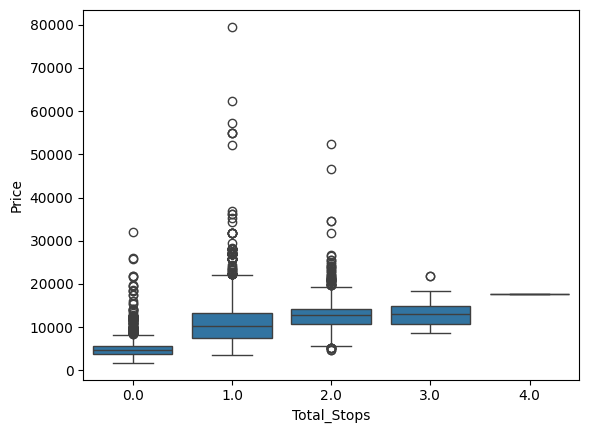

In [36]:
sns.boxplot(x='Total_Stops', y='Price', data=df)

<Axes: xlabel='Price', ylabel='Count'>

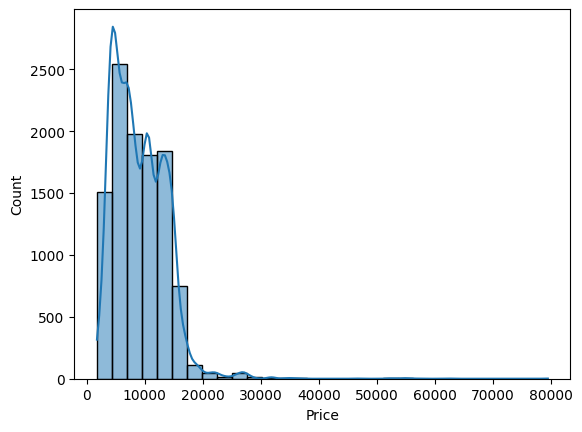

In [37]:
sns.histplot(df['Price'], bins=30, kde=True)

In [38]:
oneHotencoder=OneHotEncoder()
additional_info_encoded= oneHotencoder.fit_transform(df[['Additional_Info']]).toarray()
additional_info_encoded_df=pd.DataFrame(additional_info_encoded, columns=oneHotencoder.get_feature_names_out(['Additional_Info']))
df = pd.concat([df, additional_info_encoded_df], axis=1)


In [39]:
df.drop('Additional_Info', axis=1, inplace=True)

In [40]:
df.head(4)

,Total_Stops,Price,Day,Month,Year,Arrival_Hour,Arrival_Minute,Departure_hour,Departure_minute,Duration_Time,...,Additional_Info_1 Short layover,Additional_Info_2 Long layover,Additional_Info_Business class,Additional_Info_Change airports,Additional_Info_In-flight meal not included,Additional_Info_No Info,Additional_Info_No check-in baggage included,Additional_Info_No info,Additional_Info_Red-eye flight,Additional_Info_nan
0,0.0,3897.0,24.0,3.0,2019.0,1.0,10.0,22.0,20.0,170.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,2.0,7662.0,1.0,5.0,2019.0,13.0,15.0,5.0,50.0,445.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,2.0,13882.0,9.0,6.0,2019.0,4.0,25.0,9.0,25.0,1140.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,6218.0,12.0,5.0,2019.0,23.0,30.0,18.0,5.0,325.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [41]:
df.to_csv('cleaned_flight_data.csv', index=False)